# Cadenas de Markov de Tiempo Continuo
## Análisis en Estado Estable

---

**Modelado bajo Incertidumbre**  
Departamento de Ingeniería Industrial · Universidad de los Andes  
*Semana 9 · Módulo 2*

## Agenda

1. Distribución estacionaria
2. Balance global y balance detallado
3. Solución numérica del estado estable
4. Cadenas de nacimiento y muerte
5. Aplicación: Cola M/M/1
6. Sensibilidad al factor de utilización ρ
7. Ejercicio: Metro de Bogotá
8. Resumen y conclusiones


# Análisis en Estado Estable
## Distribución Estacionaria

## Definición de Estado Estable

Una CTMC **ergódica** (irreducible y positiva recurrente) converge a una distribución estacionaria $\boldsymbol{\pi}^*$:

$$\lim_{t \to \infty} \boldsymbol{\pi}(t) = \boldsymbol{\pi}^*$$

En estado estable, las probabilidades **no cambian**: $\frac{d\boldsymbol{\pi}^*}{dt} = \mathbf{0}$

Entonces se debe cumplir:

$$\boxed{\boldsymbol{\pi}^* Q = \mathbf{0}}$$

junto con la condición de normalización:

$$\sum_j \pi^*_j = 1$$

## Balance Global vs Balance Detallado

**Ecuaciones de balance global** (para todo estado $j$):

$$\nu_j \, \pi^*_j = \sum_{i \neq j} \pi^*_i \, q_{ij}$$

$$\underbrace{\text{Tasa de salida de } j}_{} = \underbrace{\text{Tasa de entrada a } j}_{}$$

**Ecuaciones de balance detallado** (condición más fuerte, para todo par $i,j$):

$$\pi^*_i \, q_{ij} = \pi^*_j \, q_{ji}$$

> Si se cumple el balance detallado, la cadena es **reversible en el tiempo**.

## Solución Numérica del Estado Estable

In [9]:
def estado_estable(Q):
    """
    Calcula la distribucion estacionaria resolviendo pi @ Q = 0
    con la restriccion sum(pi) = 1.
    """
    n = Q.shape[0]
    # Reemplazamos la ultima fila de Q^T por la restriccion de normalizacion
    A = Q.T.copy()
    A[-1, :] = 1.0
    b = np.zeros(n)
    b[-1] = 1.0
    pi_star = np.linalg.solve(A, b)
    return pi_star

pi_star = estado_estable(Q)

print("=" * 45)
print("   DISTRIBUCION EN ESTADO ESTABLE  pi*")
print("=" * 45)
for j, p in enumerate(pi_star):
    print(f"  pi*_{j} = {p:.6f}   ({p*100:.2f}%)")
print("=" * 45)
print(f"  Verificacion pi*·Q = {pi_star @ Q}")
print(f"  Suma de probabilidades = {pi_star.sum():.6f}")

   DISTRIBUCION EN ESTADO ESTABLE  pi*
  pi*_0 = 0.461538   (46.15%)
  pi*_1 = 0.282051   (28.21%)
  pi*_2 = 0.256410   (25.64%)
  Verificacion pi*·Q = [ 0.00000000e+00  0.00000000e+00 -2.22044605e-16]
  Suma de probabilidades = 1.000000


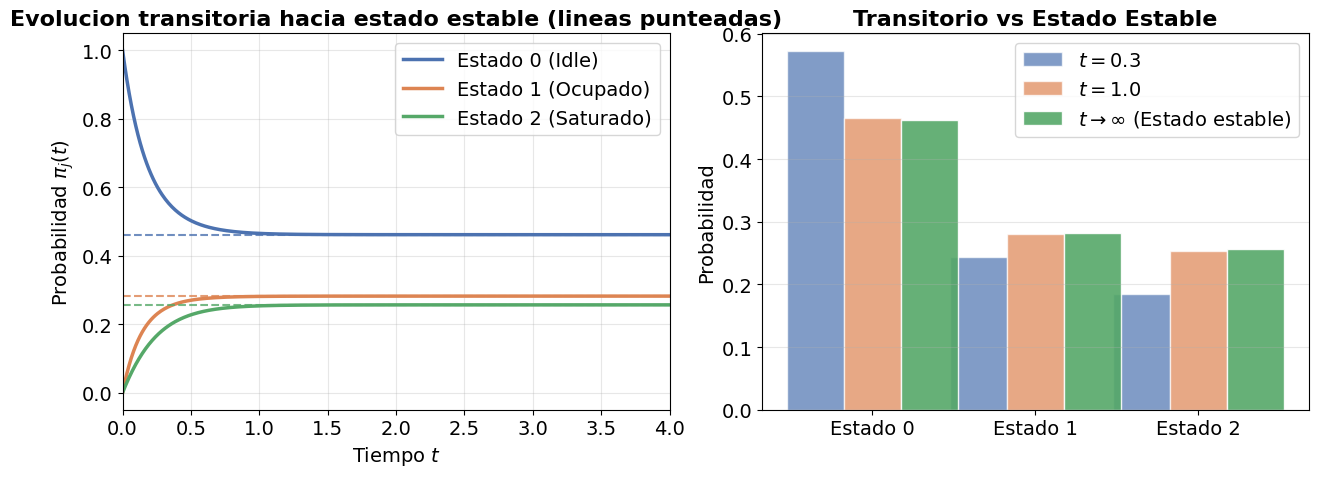

In [10]:
# Visualización: convergencia al estado estable
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax1 = axes[0]
for j in range(3):
    ax1.plot(t_vals, pi_t[:, j], color=colors[j], lw=2.5, label=labels[j])
    ax1.axhline(y=pi_star[j], color=colors[j], linestyle='--', lw=1.5, alpha=0.8)

ax1.set_xlabel('Tiempo $t$')
ax1.set_ylabel('Probabilidad $\\pi_j(t)$')
ax1.set_title('Evolucion transitoria hacia estado estable (lineas punteadas)', fontweight='bold')
ax1.legend()
ax1.set_xlim(0, T_max)
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
x = np.arange(3)
width = 0.35
pi_t1 = pi0 @ expm(Q * 0.3)
pi_t2 = pi0 @ expm(Q * 1.0)

ax2.bar(x - width, pi_t1, width, label='$t=0.3$', color='#4C72B0', alpha=0.7, edgecolor='white')
ax2.bar(x,         pi_t2, width, label='$t=1.0$', color='#DD8452', alpha=0.7, edgecolor='white')
ax2.bar(x + width, pi_star, width, label='$t\\to\\infty$ (Estado estable)', color='#55A868', alpha=0.9, edgecolor='white')

ax2.set_xticks(x)
ax2.set_xticklabels(['Estado 0', 'Estado 1', 'Estado 2'])
ax2.set_ylabel('Probabilidad')
ax2.set_title('Transitorio vs Estado Estable', fontweight='bold')
ax2.legend()
ax2.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Cadenas de Nacimiento y Muerte

Una subclase muy importante de CTMCs con **estructura tri-diagonal**:

$$Q = \begin{pmatrix}
-\lambda_0 & \lambda_0 & 0 & \cdots \\
\mu_1 & -(\lambda_1+\mu_1) & \lambda_1 & \cdots \\
0 & \mu_2 & -(\lambda_2+\mu_2) & \cdots \\
\vdots & & & \ddots
\end{pmatrix}$$

- $\lambda_i$: tasa de **nacimiento** (transición $i \to i+1$)
- $\mu_i$: tasa de **muerte** (transición $i \to i-1$)

Solución en estado estable (balance detallado):

$$\pi^*_n = \pi^*_0 \prod_{k=0}^{n-1} \frac{\lambda_k}{\mu_{k+1}}$$

In [11]:
def birth_death_Q(lambdas, mus):
    n = len(lambdas) + 1
    Q_bd = np.zeros((n, n))
    for i in range(n - 1):
        Q_bd[i, i+1] = lambdas[i]
        Q_bd[i, i]  -= lambdas[i]
    for i in range(1, n):
        Q_bd[i, i-1] = mus[i-1]
        Q_bd[i, i]  -= mus[i-1]
    return Q_bd

def bd_steady_state(lambdas, mus):
    n = len(lambdas) + 1
    pi = np.ones(n)
    for k in range(1, n):
        pi[k] = pi[k-1] * lambdas[k-1] / mus[k-1]
    return pi / pi.sum()

N_bd = 4
lam = [2.0] * N_bd
mu  = [3.0] * N_bd

Q_bd = birth_death_Q(lam, mu)
pi_bd_analitica = bd_steady_state(lam, mu)
pi_bd_numerica  = estado_estable(Q_bd)

print("Distribucion estacionaria (Nacimiento-Muerte, lambda=2, mu=3):")
print(f"{'Estado':>8} {'Analitica':>12} {'Numerica':>12} {'Error':>10}")
print("-" * 46)
for j in range(N_bd + 1):
    err = abs(pi_bd_analitica[j] - pi_bd_numerica[j])
    print(f"{j:>8} {pi_bd_analitica[j]:>12.6f} {pi_bd_numerica[j]:>12.6f} {err:>10.2e}")

Distribucion estacionaria (Nacimiento-Muerte, lambda=2, mu=3):
  Estado    Analitica     Numerica      Error
----------------------------------------------
       0     0.383886     0.383886   2.22e-16
       1     0.255924     0.255924   1.11e-16
       2     0.170616     0.170616   2.78e-17
       3     0.113744     0.113744   1.39e-17
       4     0.075829     0.075829   0.00e+00


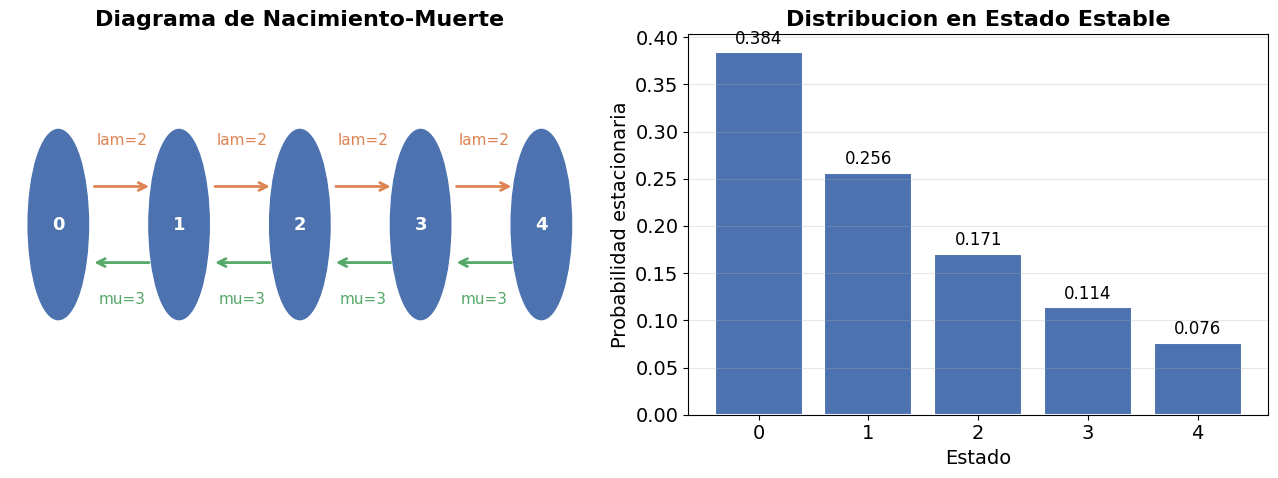

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
estados = range(N_bd + 1)

# Diagrama de nacimiento-muerte
ax_diag = axes[0]
for i in estados:
    circle = plt.Circle((i * 2, 0), 0.5, color='#4C72B0', zorder=3)
    ax_diag.add_patch(circle)
    ax_diag.text(i * 2, 0, str(i), ha='center', va='center',
                 color='white', fontweight='bold', fontsize=13, zorder=4)
    if i < N_bd:
        ax_diag.annotate('', xy=(i*2 + 1.55, 0.2), xytext=(i*2 + 0.55, 0.2),
                         arrowprops=dict(arrowstyle='->', color='#DD8452', lw=2))
        ax_diag.text(i*2 + 1.05, 0.42, f'lam={lam[i]:.0f}', ha='center',
                     color='#DD8452', fontsize=11)
        ax_diag.annotate('', xy=(i*2 + 0.55, -0.2), xytext=(i*2 + 1.55, -0.2),
                         arrowprops=dict(arrowstyle='->', color='#55A868', lw=2))
        ax_diag.text(i*2 + 1.05, -0.42, f'mu={mu[i]:.0f}', ha='center',
                     color='#55A868', fontsize=11)

ax_diag.set_xlim(-0.8, (N_bd)*2 + 0.8)
ax_diag.set_ylim(-1, 1)
ax_diag.set_title('Diagrama de Nacimiento-Muerte', fontweight='bold')
ax_diag.axis('off')

# Distribución estacionaria
ax_dist = axes[1]
bars = ax_dist.bar(estados, pi_bd_analitica, color='#4C72B0', edgecolor='white', linewidth=1.5)
ax_dist.set_xlabel('Estado')
ax_dist.set_ylabel('Probabilidad estacionaria')
ax_dist.set_title('Distribucion en Estado Estable', fontweight='bold')
ax_dist.grid(True, axis='y', alpha=0.3)
for bar, val in zip(bars, pi_bd_analitica):
    ax_dist.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()

## Aplicación: Cola M/M/1

Un servidor con llegadas Poisson y servicio exponencial:

| Parámetro | Descripción |
|:---------:|:-----------:|
| $\lambda$ | Tasa de llegadas (clientes/hora) |
| $\mu$ | Tasa de servicio (clientes/hora) |
| $\rho = \lambda/\mu$ | Factor de utilización |

Es una cadena de nacimiento-muerte con **estados = número de clientes en el sistema**.

**Condición de estabilidad**: $\rho < 1$

**Distribución estacionaria**: $\pi^*_n = (1-\rho)\,\rho^n$

In [13]:
# ============================================================
# COLA M/M/1 — Análisis completo
# ============================================================
lam_mm1 = 3.0   # llegadas por hora
mu_mm1  = 5.0   # servicio por hora
rho     = lam_mm1 / mu_mm1
N_trunc = 15

n_vals = np.arange(N_trunc)
pi_mm1_analitica = (1 - rho) * rho**n_vals

lam_bd = [lam_mm1] * (N_trunc - 1)
mu_bd  = [mu_mm1]  * (N_trunc - 1)
Q_mm1  = birth_death_Q(lam_bd, mu_bd)
pi_mm1_num = estado_estable(Q_mm1)

# Métricas de rendimiento (Fórmulas de Little)
L  = rho / (1 - rho)
Lq = rho**2 / (1 - rho)
W  = 1 / (mu_mm1 - lam_mm1)
Wq = rho / (mu_mm1 - lam_mm1)

print(f"  Cola M/M/1:  lambda={lam_mm1}, mu={mu_mm1}, rho={rho:.2f}")
print("=" * 45)
print(f"  L  (# en sistema)   = {L:.4f} clientes")
print(f"  Lq (# en cola)      = {Lq:.4f} clientes")
print(f"  W  (tiempo sistema) = {W*60:.2f} minutos")
print(f"  Wq (tiempo cola)    = {Wq*60:.2f} minutos")
print(f"  Utilizacion rho     = {rho*100:.1f}%")

  Cola M/M/1:  lambda=3.0, mu=5.0, rho=0.60
  L  (# en sistema)   = 1.5000 clientes
  Lq (# en cola)      = 0.9000 clientes
  W  (tiempo sistema) = 30.00 minutos
  Wq (tiempo cola)    = 18.00 minutos
  Utilizacion rho     = 60.0%


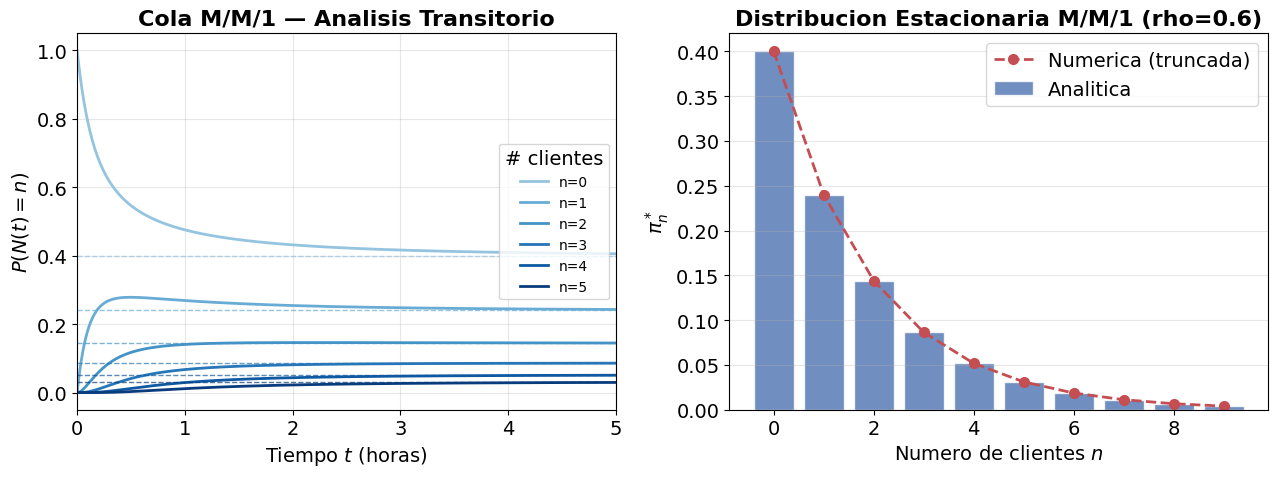

In [14]:
# Análisis transitorio de la cola M/M/1
pi0_mm1 = np.zeros(N_trunc)
pi0_mm1[0] = 1.0

t_mm1 = np.linspace(0, 5, 400)
pi_mm1_t = np.array([pi0_mm1 @ expm(Q_mm1 * t) for t in t_mm1])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax1 = axes[0]
cmap_blues = plt.cm.Blues(np.linspace(0.4, 0.95, 6))
for n in range(6):
    ax1.plot(t_mm1, pi_mm1_t[:, n], color=cmap_blues[n], lw=2, label=f'n={n}')
    ax1.axhline(y=pi_mm1_analitica[n], color=cmap_blues[n], linestyle='--', lw=1, alpha=0.7)

ax1.set_xlabel('Tiempo $t$ (horas)')
ax1.set_ylabel('$P(N(t) = n)$')
ax1.set_title('Cola M/M/1 — Analisis Transitorio', fontweight='bold')
ax1.legend(title='# clientes', loc='right', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 5)

ax2 = axes[1]
ax2.bar(n_vals[:10], pi_mm1_analitica[:10], color='#4C72B0', label='Analitica', alpha=0.8, edgecolor='white')
ax2.plot(n_vals[:10], pi_mm1_num[:10], 'o--', color='#C44E52', lw=2, ms=7, label='Numerica (truncada)')
ax2.set_xlabel('Numero de clientes $n$')
ax2.set_ylabel('$\\pi^*_n$')
ax2.set_title(f'Distribucion Estacionaria M/M/1 (rho={rho:.1f})', fontweight='bold')
ax2.legend()
ax2.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Sensibilidad al Factor de Utilización ρ

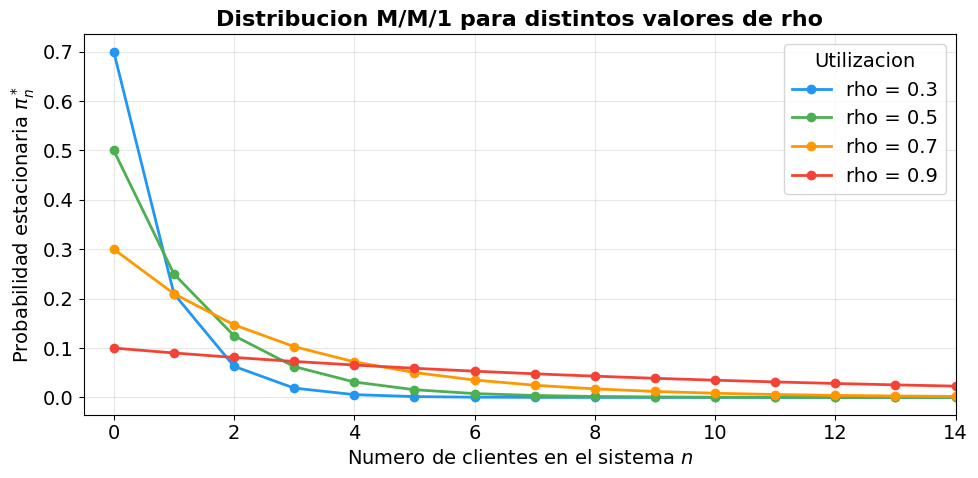

In [15]:
rho_vals = [0.3, 0.5, 0.7, 0.9]
fig, ax = plt.subplots(figsize=(10, 5))
cmap_rho = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']

for rho_i, color in zip(rho_vals, cmap_rho):
    pi_i = (1 - rho_i) * rho_i**n_vals
    ax.plot(n_vals, pi_i, 'o-', color=color, lw=2, ms=6, label=f'rho = {rho_i}')

ax.set_xlabel('Numero de clientes en el sistema $n$')
ax.set_ylabel('Probabilidad estacionaria $\\pi^*_n$')
ax.set_title('Distribucion M/M/1 para distintos valores de rho', fontweight='bold')
ax.legend(title='Utilizacion')
ax.grid(True, alpha=0.3)
ax.set_xlim(-0.5, 14)
plt.tight_layout()
plt.show()

## Ejercicio: Metro de Bogotá

La Primera Línea del Metro de Bogotá contará con 16 estaciones. Las 3 estaciones con mayor afluencia son:

| Estación | Capacidad | Tiempo trenes (min) | Llegada usuarios |
|:---------|:---------:|:-------------------:|:----------------:|
| Av. Primero de Mayo (Boyacá – Cra 72C) | 57 | 4 | Exp(λ = 11.94 min⁻¹) |
| Av. NQS (Diagonal 16S – Calle 17A Bis) | 256 | 7 | Exp(λ = 8.96 min⁻¹) |
| Av. Caracas (Calles 24A – 26) | 213 | 25 | Exp(λ = 15.55 min⁻¹) |

**Capacidad máxima del tren:** 180 pasajeros.  
Si la estación está llena, los usuarios adicionales toman otro medio de transporte.  
**Todas las estaciones comienzan vacías.**

**Objetivo:** Estimar $E[X(t)]$ y $\text{Var}(X(t))$ durante la primera hora, y la probabilidad de que cada estación esté completamente llena en estado estable.

## Modelo CTMC — Metro de Bogotá

$X_d(t)$ = número de usuarios en la estación $d$ en el instante $t$

$$S_d = \{0, 1, 2, \ldots, n_d\}$$

**Matriz generadora** $Q^d$:

$$Q^d_{i \to j} = \begin{cases}
\lambda_d & j = i+1,\quad i < n_d \quad\text{(llega usuario)}\\
\mu_d & j = \max(0,\, i - 180),\quad i > 0 \quad\text{(llega tren)}\\
0 & \text{d.l.c.}
\end{cases}$$

donde $\mu_d = 1/\text{tiempo entre trenes}$ y la capacidad del tren es 180 pasajeros.

> Si $i \leq 180$: el tren se lleva a todos → estado 0.  
> Si $i > 180$: quedan $i - 180$ usuarios esperando.

## Medidas de Interés

Con condición inicial $\boldsymbol{\pi}(0) = [1, 0, 0, \ldots, 0]$ (estación vacía):

**Valor esperado:**
$$E[X(t)] = \boldsymbol{\pi}(0)\, e^{Qt}\, S_{X_d}^{\top}$$

**Segundo momento:**
$$E[X^2(t)] = \boldsymbol{\pi}(0)\, e^{Qt}\, (S_{X_d}^{2})^{\top}$$

**Varianza:**
$$\text{Var}(X(t)) = E[X^2(t)] - \bigl[E[X(t)]\bigr]^2$$

donde $S_{X_d} = (0, 1, 2, \ldots, n_d)$ es el vector de estados.

In [ ]:
# ============================================================
# METRO DE BOGOTÁ — Construcción de la Matriz Q
# ============================================================

def build_metro_Q(lam, mu, capacity, train_cap=180):
    """
    Construye la matriz Q para una estación de metro.
    lam      : tasa de llegada de usuarios (por minuto)
    mu       : tasa de llegada de trenes (por minuto) = 1/tiempo_entre_trenes
    capacity : capacidad máxima de la estación
    train_cap: capacidad máxima del tren (default 180)
    """
    n = capacity + 1  # estados 0, 1, ..., capacity
    Q = np.zeros((n, n))
    for i in range(n):
        if i < capacity:           # llega usuario → i+1
            Q[i, i + 1] = lam
        if i > 0:                  # llega tren → max(0, i-180)
            dest = max(0, i - train_cap)
            Q[i, dest] += mu
        Q[i, i] = -Q[i, :].sum()  # diagonal
    return Q

# Parámetros de cada estación
TRAIN_CAP = 180
estaciones = [
    {'nombre': 'Av. Primero de Mayo\n(Boyacá – Cra 72C)',
     'lam': 11.94, 'mu': 1/4,  'cap': 57},
    {'nombre': 'Av. NQS\n(Diagonal 16S – Calle 17A)',
     'lam': 8.96,  'mu': 1/7,  'cap': 256},
    {'nombre': 'Av. Caracas\n(Calles 24A – 26)',
     'lam': 15.55, 'mu': 1/25, 'cap': 213},
]

# Verificar la construcción con la estación pequeña
Q_test = build_metro_Q(estaciones[0]['lam'], estaciones[0]['mu'], estaciones[0]['cap'])
print(f"Estación 1 — Tamaño Q: {Q_test.shape}")
print(f"Verificación filas suman 0: max|suma| = {np.abs(Q_test.sum(axis=1)).max():.2e}")
print(f"\nEjemplo fila i=0  : q_{{0,1}}={Q_test[0,1]:.2f} (λ), q_{{0,0}}={Q_test[0,0]:.2f}")
print(f"Ejemplo fila i=50 : q_{{50,0}}={Q_test[50,0]:.4f} (μ), q_{{50,51}}={Q_test[50,51]:.2f} (λ)")
print(f"Ejemplo fila i=57 (llena): q_{{57,0}}={Q_test[57,0]:.4f} (μ), sin llegadas")

In [ ]:
# ============================================================
# ANÁLISIS TRANSITORIO — E[X(t)] y Var[X(t)] primera hora
# ============================================================

from scipy.integrate import solve_ivp

T_METRO = 60          # primera hora (minutos)
N_PUNTOS = 120        # un punto por cada 0.5 minutos
t_metro = np.linspace(0, T_METRO, N_PUNTOS)

resultados = []

for est in estaciones:
    Q_est = build_metro_Q(est['lam'], est['mu'], est['cap'])
    n_est = est['cap'] + 1
    estados_est = np.arange(n_est)

    # Condición inicial: estación vacía
    pi0_est = np.zeros(n_est)
    pi0_est[0] = 1.0

    # Resolver ecuaciones de Kolmogorov hacia adelante
    sol = solve_ivp(
        lambda t, pi: Q_est.T @ pi,
        t_span=(0, T_METRO),
        y0=pi0_est,
        t_eval=t_metro,
        method='RK45',
        rtol=1e-7, atol=1e-9
    )
    pi_t_est = sol.y.T  # (N_PUNTOS, n_est)

    # Medidas de interés
    E_t  = pi_t_est @ estados_est           # E[X(t)]
    E2_t = pi_t_est @ (estados_est ** 2)    # E[X²(t)]
    Var_t = E2_t - E_t ** 2                 # Var(X(t))

    resultados.append({'nombre': est['nombre'], 'cap': est['cap'],
                       'E': E_t, 'Var': Var_t})
    print(f"{est['nombre'].replace(chr(10),' ')} → E[X(60)]={E_t[-1]:.2f},  "
          f"Var(X(60))={Var_t[-1]:.2f}")

In [ ]:
# ============================================================
# VISUALIZACIÓN — Valor esperado y varianza por estación
# ============================================================

colors_metro = ['#4C72B0', '#DD8452', '#55A868']
nombres_cortos = ['Av. Primero de Mayo', 'Av. NQS', 'Av. Caracas']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel izquierdo — Valor esperado
ax1 = axes[0]
for res, col, nom in zip(resultados, colors_metro, nombres_cortos):
    ax1.plot(t_metro, res['E'], color=col, lw=2.5, label=nom)
    ax1.axhline(y=res['cap'], color=col, linestyle=':', lw=1.2, alpha=0.6)

ax1.set_xlabel('Tiempo (minutos)')
ax1.set_ylabel('$E[X(t)]$ — Usuarios esperados')
ax1.set_title('Valor Esperado de Usuarios en cada Estación', fontweight='bold')
ax1.legend(loc='right')
ax1.set_xlim(0, T_METRO)
ax1.grid(True, alpha=0.3)

# Anotar capacidad máxima
for res, col in zip(resultados, colors_metro):
    ax1.annotate(f"cap={res['cap']}", xy=(T_METRO, res['cap']),
                 xytext=(T_METRO - 12, res['cap'] + 3),
                 color=col, fontsize=9)

# Panel derecho — Varianza
ax2 = axes[1]
for res, col, nom in zip(resultados, colors_metro, nombres_cortos):
    ax2.plot(t_metro, res['Var'], color=col, lw=2.5, label=nom)

ax2.set_xlabel('Tiempo (minutos)')
ax2.set_ylabel('$\\text{Var}(X(t))$ — Varianza de usuarios')
ax2.set_title('Varianza del Número de Usuarios en cada Estación', fontweight='bold')
ax2.legend(loc='right')
ax2.set_xlim(0, T_METRO)
ax2.grid(True, alpha=0.3)

plt.suptitle('Análisis Transitorio — Metro de Bogotá (primera hora)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# ESTADO ESTABLE — Probabilidad de estación completamente llena
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

print(f"{'Estación':45} {'P(llena)':>10}  {'ρ = λ/μ':>10}")
print("-" * 70)

for est, ax, col, nom in zip(estaciones, axes, colors_metro, nombres_cortos):
    Q_est = build_metro_Q(est['lam'], est['mu'], est['cap'])
    pi_ss = estado_estable(Q_est)

    p_full = pi_ss[est['cap']]
    rho_est = est['lam'] / est['mu']  # carga del sistema
    print(f"{nom:45} {p_full:>10.6f}  {rho_est:>10.2f}")

    # Gráfica de la distribución (primeros 40 estados o todos si < 40)
    n_show = min(40, est['cap'] + 1)
    estados_show = np.arange(n_show)
    bars = ax.bar(estados_show, pi_ss[:n_show], color=col, alpha=0.85, edgecolor='white')
    ax.axvline(x=est['cap'], color='red', linestyle='--', lw=1.5,
               label=f'Capacidad ({est["cap"]})')
    ax.set_title(f'{nom}\nP(llena) = {p_full:.4%}', fontweight='bold', fontsize=11)
    ax.set_xlabel('Número de usuarios')
    ax.set_ylabel('Probabilidad estacionaria')
    ax.legend(fontsize=9)
    ax.grid(True, axis='y', alpha=0.3)

plt.suptitle('Distribución en Estado Estable — Metro de Bogotá', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Resumen: Análisis Transitorio vs Estado Estable

| Característica | Análisis Transitorio | Estado Estable |
|:---|:---:|:---:|
| **Pregunta** | ¿Cómo evoluciona el sistema? | ¿A dónde converge? |
| **Resultado** | $\boldsymbol{\pi}(t)$ función del tiempo | $\boldsymbol{\pi}^*$ constante |
| **Ecuación** | $\dot{\boldsymbol{\pi}} = \boldsymbol{\pi} Q$ | $\boldsymbol{\pi}^* Q = \mathbf{0}$ |
| **Solución** | $\boldsymbol{\pi}(t) = \boldsymbol{\pi}(0)\,e^{Qt}$ | Sistema lineal + normalización |
| **Dependencia** | Condición inicial $\boldsymbol{\pi}(0)$ | Independiente del estado inicial |
| **Costo comp.** | Mayor (exponencial matricial) | Menor (álgebra lineal) |

## Condiciones de Existencia del Estado Estable

La distribución estacionaria **existe y es única** si la cadena es:

1. **Irreducible**: todo estado es alcanzable desde cualquier otro estado.
2. **Positiva recurrente**: el tiempo esperado de retorno a cualquier estado es finito.

Para espacios de estados finitos: **irreducibilidad implica positiva recurrencia**.

Para cadenas de nacimiento-muerte infinitas:

$$\sum_{n=0}^{\infty} \prod_{k=0}^{n-1} \frac{\lambda_k}{\mu_{k+1}} < \infty \quad \Longleftrightarrow \quad \text{Estado estable existe}$$

## Conclusiones

Las **Cadenas de Markov de Tiempo Continuo** son una herramienta fundamental para modelar:

- Sistemas de colas (M/M/1, M/M/c, M/M/∞)
- Confiabilidad y mantenimiento de equipos
- Modelos epidemiológicos (SIR, SEIR)
- Redes de comunicación y sistemas computacionales

**Flujo de trabajo:**

```
Definir estados  →  Construir Q  →  Análisis transitorio  →  Estado estable
                                    (dinámica temporal)        (largo plazo)
```

**Receta en Python:**
```python
from scipy.linalg import expm

pi_t     = pi0 @ expm(Q * t)          # transitorio
pi_star  = np.linalg.solve(A, b)       # estado estable
```